In [6]:
# import packages
import pandas as pd
import numpy as np
import statsmodels.api as sm

# load datasets
ftse = pd.read_csv("ftse_350_monthly.csv")
price_paid = pd.read_csv("price_paid_monthly.csv")
sanctions = pd.read_csv("sanctioned_monthly.csv")

# date columns to datetime to merge
ftse["Date"] = pd.to_datetime(ftse["Date"])
price_paid["month"] = pd.to_datetime(price_paid["month"])
sanctions["month"] = pd.to_datetime(sanctions["month"])

ftse = ftse[["Date", "Price"]].rename(columns={"Date": "month", "Price": "ftse_price"})
price_paid = price_paid[["month", "property_count", "total_value"]]
sanctions = sanctions[["month", "unique_sanctioned_people"]]

start_month = min(
    ftse["month"].min(),
    price_paid["month"].min(),
    sanctions["month"].min())

end_month = max(
    ftse["month"].max(),
    price_paid["month"].max(),
    sanctions["month"].max())

# merge all datasets into one calendar
calendar = pd.DataFrame({"month": pd.date_range(start=start_month, end=end_month, freq="MS")})
df = calendar.merge(ftse, on="month", how="left")
df = df.merge(price_paid, on="month", how="left")
df = df.merge(sanctions, on="month", how="left")
df = df.sort_values("month").reset_index(drop=True)

# months with no sanctions are treated as zero
df["unique_sanctioned_people"] = df["unique_sanctioned_people"].fillna(0)

df = df[df["month"] >= "2014-03-01"].copy()

# FTSE monthly log return
df["ftse_return"] = np.log(df["ftse_price"] / df["ftse_price"].shift(1))

# property market growth rates using log changes
df["property_count_growth"] = np.log(df["property_count"] / df["property_count"].shift(1))
df["total_value_growth"] = np.log(df["total_value"] / df["total_value"].shift(1))

# average transaction price and its growth
df["avg_price"] = df["total_value"] / df["property_count"]
df["avg_price_growth"] = np.log(df["avg_price"] / df["avg_price"].shift(1))

df["sanctions_size_weighted"] = np.log1p(df["unique_sanctioned_people"])

# create lagged versions of one variable
def add_lags(data, varname, max_lag):
    data = data.copy()
    for lag in range(max_lag + 1):
        data[f"{varname}_lag{lag}"] = data[varname].shift(lag)
    return data

# Main distributed-lag regression
# checks whether sanctions this month and previous months relate to the outcome
def run_lag_regression(data, y_var, event_var="sanctions_size_weighted", max_lag=6, add_controls=True):
    """
    Model:
    Y_t = a + b0*event_t + b1*event_t-1 + ... + bk*event_t-k + controls + error

    event_var here is monthly sanctions intensity.
    """
    data = add_lags(data, event_var, max_lag)

    lag_cols = [f"{event_var}_lag{lag}" for lag in range(max_lag + 1)]
    x_cols = lag_cols.copy()

    reg = data[[y_var] + x_cols].dropna().copy()

    X = sm.add_constant(reg[x_cols])
    y = reg[y_var]

    model = sm.OLS(y, X).fit()
    return model

# test different lag lengths and compare fit statistics
def find_optimal_lag(data, y_var, event_var="sanctions_size_weighted", max_test_lag=12, add_controls=True):
    results = []

    for lag in range(1, max_test_lag + 1):
        try:
            model = run_lag_regression(
                data=data,
                y_var=y_var,
                event_var=event_var,
                max_lag=lag,
                add_controls=add_controls
            )
            results.append({
                "max_lag": lag,
                "nobs": model.nobs,
                "aic": model.aic,
                "bic": model.bic,
                "adj_r2": model.rsquared_adj
            })
        except Exception as e:
            print(f"Could not fit lag {lag} for {y_var}: {e}")

    return pd.DataFrame(results).sort_values("max_lag")

# lag coefficients and confidence intervals from a fitted model
def extract_lag_coefficients(model, event_var):
    rows = []
    conf = model.conf_int()

    for name in model.params.index:
        if event_var in name:
            rows.append({
                "variable": name,
                "coef": model.params[name],
                "p_value": model.pvalues[name],
                "ci_low": conf.loc[name, 0],
                "ci_high": conf.loc[name, 1]
            })

    out = pd.DataFrame(rows)
    out["lag"] = out["variable"].str.extract(r"lag(\d+)").astype(int)
    out = out.sort_values("lag").reset_index(drop=True)
    return out

# event-study average around sanction months - what happens before and after an event month
def event_study_average(data, y_var, event_dates, window=6):
    rows = []
    data = data.sort_values("month").reset_index(drop=True)
    date_to_idx = {d: i for i, d in enumerate(data["month"])}

    for event_date in event_dates:
        if event_date not in date_to_idx:
            continue

        event_idx = date_to_idx[event_date]

        for rel_t in range(-window, window + 1):
            idx = event_idx + rel_t
            if 0 <= idx < len(data):
                rows.append({
                    "event_date": event_date,
                    "rel_t": rel_t,
                    "y": data.loc[idx, y_var]})

    out = pd.DataFrame(rows)
    avg = out.groupby("rel_t")["y"].mean().reset_index()
    return avg

outcomes = [
    "property_count_growth",
    "total_value_growth",
    "avg_price_growth",
    "ftse_return"]

# choose the best lag model
event_var = "sanctions_size_weighted"
best_models = {}
lag_tables = {}

for y in outcomes:
    lag_table = find_optimal_lag(
        data=df,
        y_var=y,
        event_var=event_var,
        max_test_lag=12,
        add_controls=True
    )
    lag_tables[y] = lag_table

    print(f"LAG COMPARISON FOR {y}")
    print(lag_table)

    best_lag = int(lag_table.loc[lag_table["bic"].idxmin(), "max_lag"])
    print(f"Best lag for {y} by BIC: {best_lag}")

    model = run_lag_regression(
        data=df,
        y_var=y,
        event_var=event_var,
        max_lag=best_lag,
        add_controls=True
    )
    best_models[y] = model

#print
for y, model in best_models.items():
    print(f"FINAL MODEL FOR {y}")
    print(model.summary())
for y, model in best_models.items():
    effects = extract_lag_coefficients(model, event_var)

    print(f"LAG EFFECTS FOR {y}")
    print(effects)

# create leads and lags for a pre-trend check - leads check whether the outcome starts changing before sanctions happen
def add_leads_and_lags(data, varname, max_lead=3, max_lag=1):
    data = data.copy()

    for lead in range(1, max_lead + 1):
        data[f"{varname}_lead{lead}"] = data[varname].shift(-lead)

    for lag in range(0, max_lag + 1):
        data[f"{varname}_lag{lag}"] = data[varname].shift(lag)

    return data

# regression for pre-trend testing
def run_pretrend_regression(data, y_var, event_var="sanctions_size_weighted", max_lead=3, max_lag=1, add_controls=True):
    """
    Tests whether outcome changes BEFORE future sanctions intensity arrives.
    """
    data = add_leads_and_lags(data, event_var, max_lead=max_lead, max_lag=max_lag)

    lead_cols = [f"{event_var}_lead{i}" for i in range(1, max_lead + 1)]
    lag_cols = [f"{event_var}_lag{i}" for i in range(0, max_lag + 1)]
    x_cols = lead_cols + lag_cols

    reg = data[[y_var] + x_cols].dropna().copy()

    X = sm.add_constant(reg[x_cols])
    y = reg[y_var]

    model = sm.OLS(y, X).fit()
    return model

# format coefficients from the pre-trend model into a simple table
def extract_pretrend_coefficients(model, event_var):
    rows = []
    conf = model.conf_int()

    for name in model.params.index:
        if event_var in name:
            period_type = None
            period_num = None

            if "lead" in name:
                period_type = "lead"
                period_num = int(name.split("lead")[1])
            elif "lag" in name:
                period_type = "lag"
                period_num = int(name.split("lag")[1])

            rows.append({
                "variable": name,
                "type": period_type,
                "period": period_num,
                "coef": model.params[name],
                "p_value": model.pvalues[name],
                "ci_low": conf.loc[name, 0],
                "ci_high": conf.loc[name, 1]
            })

    out = pd.DataFrame(rows)
    out["event_time"] = np.where(out["type"] == "lead", -out["period"], out["period"])
    out = out.sort_values("event_time").reset_index(drop=True)
    return out

# property outcomes used for the pre-trend test
pretrend_outcomes = [
    "property_count_growth",
    "total_value_growth",
    "avg_price_growth"
]

pretrend_models = {}
pretrend_effects = {}

for y in pretrend_outcomes:
    model = run_pretrend_regression(
        data=df,
        y_var=y,
        event_var="sanctions_size_weighted",
        max_lead=3,
        max_lag=1,
        add_controls=True
    )

    pretrend_models[y] = model

    print(f"PRE-TREND / ANTICIPATION MODEL FOR {y}")
    print(model.summary())

    effects = extract_pretrend_coefficients(model, "sanctions_size_weighted")
    pretrend_effects[y] = effects

    print("Lead/Lag effects:")
    print(effects)

# joint test]
def test_all_pretrends_zero(model, event_var="sanctions_size_weighted", max_lead=3):
    restrictions = " = 0, ".join(
        [f"{event_var}_lead{i}" for i in range(1, max_lead + 1)]
    ) + " = 0"
    test = model.f_test(restrictions)
    return test

for y, model in pretrend_models.items():
    test = test_all_pretrends_zero(
        model,
        event_var="sanctions_size_weighted",
        max_lead=3
    )
    print(f"JOINT TEST OF PRE-EVENT ACTIVITY FOR {y}")
    print(test)



LAG COMPARISON FOR property_count_growth
    max_lag   nobs        aic         bic    adj_r2
0         1  141.0  74.931642   83.777921 -0.004559
1         2  140.0  73.806700   85.573270  0.013320
2         3  139.0  76.192750   90.865120  0.006703
3         4  138.0  78.294652   95.858174  0.000527
4         5  137.0  79.991442  100.431308 -0.003627
5         6  136.0  81.681172  104.982411 -0.005978
6         7  135.0  83.550077  109.697550 -0.009909
7         8  134.0  84.819726  113.798124 -0.009174
8         9  133.0  86.734259  118.528099 -0.017079
9        10  132.0  86.844394  121.438017 -0.012109
10       11  131.0  88.475848  125.853413 -0.018028
11       12  130.0  89.360360  129.505842 -0.014962
Best lag for property_count_growth by BIC: 1
LAG COMPARISON FOR total_value_growth
    max_lag   nobs         aic         bic    adj_r2
0         1  141.0   97.612580  106.458860 -0.002765
1         2  140.0   94.099796  105.866366  0.031165
2         3  139.0   95.891389  110.56375

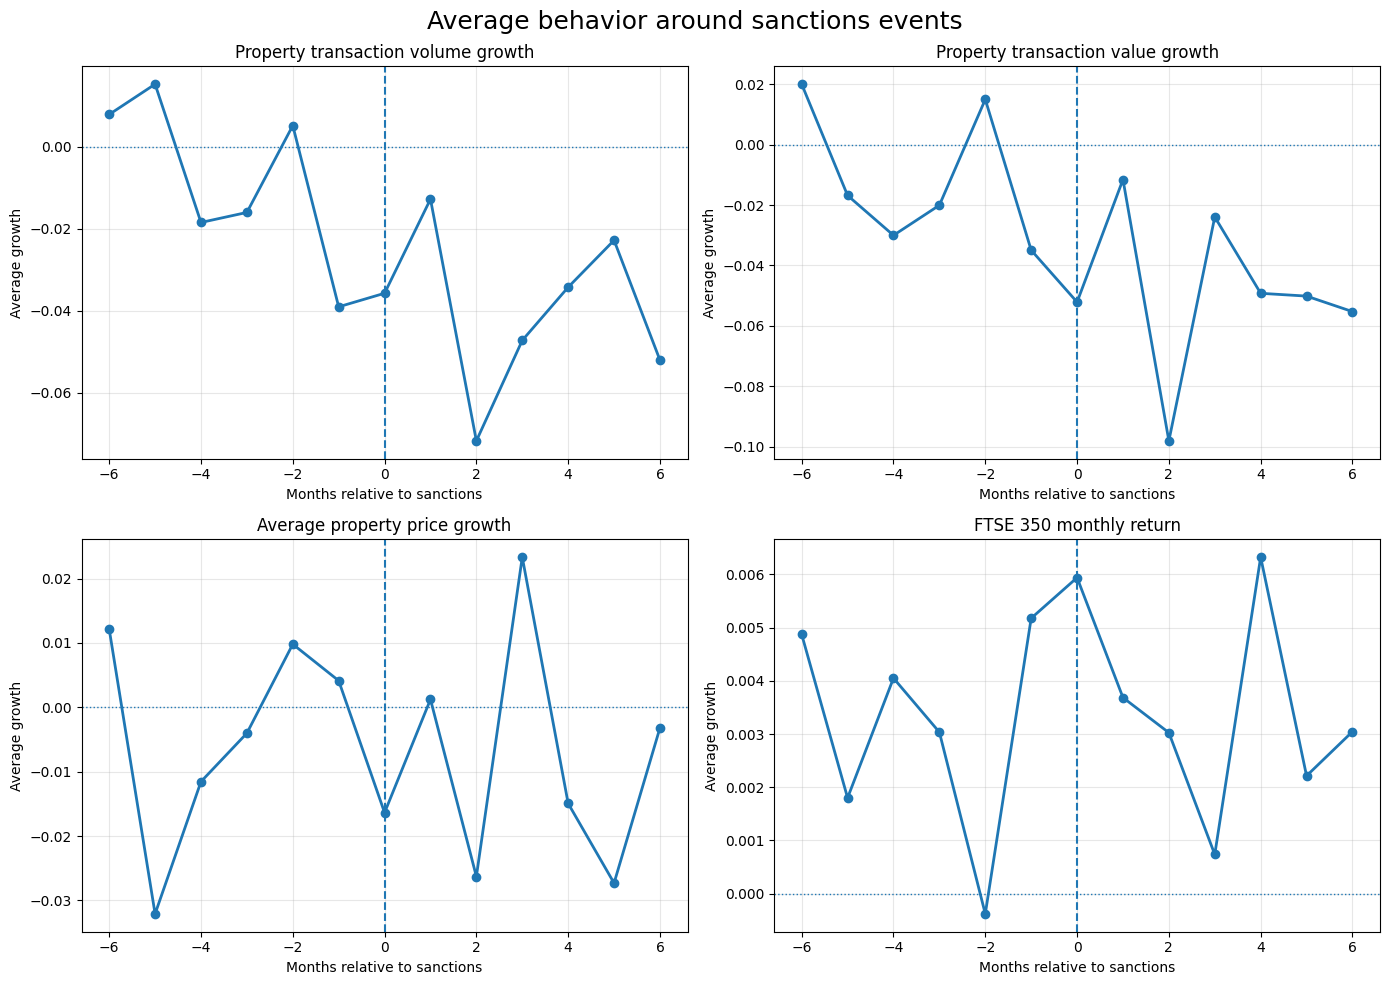

In [7]:
import matplotlib.pyplot as plt

# event months = where at least one sanctioned person appears
event_months = df.loc[df["unique_sanctioned_people"] > 0, "month"]

# outcomes to plot around sanction months
event_outcomes = [
    "property_count_growth",
    "total_value_growth",
    "avg_price_growth",
    "ftse_return"
]

# nicer names for plots
pretty_names = {
    "property_count_growth": "Property transaction volume growth",
    "total_value_growth": "Property transaction value growth",
    "avg_price_growth": "Average property price growth",
    "ftse_return": "FTSE 350 monthly return"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, y in zip(axes, event_outcomes):
    avg = event_study_average(
        data=df,
        y_var=y,
        event_dates=event_months,
        window=6
    )

    ax.plot(avg["rel_t"], avg["y"], marker="o", linewidth=2)

    # vertical line = event month, horizontal line = zero growth
    ax.axvline(0, linestyle="--", linewidth=1.5)
    ax.axhline(0, linestyle=":", linewidth=1)

    ax.set_title(pretty_names[y])
    ax.set_xlabel("Months relative to sanctions")
    ax.set_ylabel("Average growth")
    ax.grid(True, alpha=0.3)

fig.suptitle("Average behavior around sanctions events", fontsize=18)
plt.tight_layout()
plt.show()

